# Phuket Real Estate Market Analysis
**Author:** Tamirlan  
**Date:** April 2026  
**Data Source:** [200k+ Homes for Sale in Thailand - Kaggle](https://www.kaggle.com/datasets/polartech/200k-homes-for-sale-in-thailand)

## Objective
Analyze the Phuket real estate market to uncover pricing patterns, identify high-value areas, and compare property types.

## Questions We Will Answer
1. What is the price distribution of properties in Phuket?
2. How does price per sqm vary across districts?
3. Which property type offers the best value?
4. What features (size, bedrooms, bathrooms) drive the price most?
5. Which areas are the most affordable vs. most premium?

## 1. Setup - Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import matplotlib.cm as cm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# Load the full Thailand dataset
df_raw = pd.read_csv('../data/raw/thailand_homes.csv')

print(f'Total rows: {len(df_raw):,}')
df_raw.head(2)

Total rows: 220,557


,sub_property_type,agent_name,living_space,land_space_raw,price_per_unit,price_max,searched_field,bathroom_number,property_status,search_date,...,longitude,property_street_address,land_space_unit,short_description,property_type_searched,property_url,tenure,parking_number,listing_headline,agent_email
0,For Sale,คุณโบว์ 095-405-8716,280.0,271.2 sqm,฿84623.8938 / sqm,22950000.0,TH1001_2_1.html,NaN,ACT,NaN,...,100.493890,"Ban Phan Thom, Phra Nakhon, Bangkok",sqm,NaN,For_Sale,https://www.ddproperty.com/en/property/bh-0107...,Freehold,NaN,BH_01075 ขาย บ้านเดี่ยว ติด กระทรวงเกษตรและสห...,NaN
1,For Sale,Nakornthong Property,NaN,328 sqm,฿48780.4878 / sqm,16000000.0,TH1001_2_1.html,NaN,ACT,NaN,...,100.502005,"Ban Phan Thom, Phra Nakhon, Bangkok",sqm,NaN,For_Sale,https://www.ddproperty.com/en/property/ที่ดินพ...,NaN,NaN,ที่ดินพร้อมบ้านไม้ ถนนประชาธิปไตย,NaN


## 2. Filter for Phuket

In [3]:
df_raw['state'].unique()

array(['Bangkok', 'Samut Prakan', 'Nonthaburi', 'Pathum Thani',
       'Phra Nakhon Si Ayutthaya', 'Ang Thong', 'Lop Buri', 'Sing Buri',
       'Chai Nat', 'Saraburi', 'Chon Buri', 'Rayong', 'Chanthaburi',
       'Trat', 'Chachoengsao', 'Prachin Buri', 'Nakhon Nayok', 'Sa Kaeo',
       'Nakhon Ratchasima', 'Buri Ram', 'Surin', 'Si Sa Ket',
       'Ubon Ratchathani', 'Yasothon', 'Chaiyaphum', 'Amnat Charoen',
       'Nong Bua Lam Phu', 'Khon Kaen', 'Udon Thani', 'Loei', 'Nong Khai',
       'Maha Sarakham', 'Roi Et', 'Kalasin', 'Sakon Nakhon',
       'Nakhon Phanom', 'Mukdahan', 'Chiang Mai', 'Lamphun', 'Lampang',
       'Uttaradit', 'Phrae', 'Nan', 'Phayao', 'Chiang Rai',
       'Mae Hong Son', 'Nakhon Sawan', 'Uthai Thani', 'Kamphaeng Phet',
       'Tak', 'Sukhothai', 'Phitsanulok', 'Phichit', 'Phetchabun',
       'Ratchaburi', 'Kanchanaburi', 'Suphan Buri', 'Nakhon Pathom',
       'Samut Sakhon', 'Samut Songkhram', 'Phetchaburi',
       'Prachuap Khiri Khan', 'Nakhon Si Thammarat', 'K

In [4]:
# Filter for Phuket listings only
df = df_raw[df_raw['state'].str.contains('Phuket', case=False, na=False)].copy()

## 3. Exploratory Data Analysis (EDA)

In [5]:
# Drop columns with unnecessary information or 0 values for our analysis
# (latitude/longitude are KEPT for the geographic map in section 5.11)

df.drop(columns=['property_status', 'sub_property_type', 'searched_field', 'price_max', 'search_date', 'ad_type', 'apartment_number', 'building_name', 'additional_variables', 'half_bathroom_number', 'page_visits', 'room_number', 'photos_number', 'auction_date', 'reduced_date', 'reduced_date', 'videos_number', 'description', 'new_home', 'added_date', 'search_date_id', 'increased_date', 'floorplans_number', 'short_description', 'parking_number', 'agent_email', 'currency', 'price_raw', 'commercial', 'country', 'agent_url', 'property_url', 'city', 'website_searched', 'price_min', 'RUN_START_DATE', 'DATE_SCRAPED', 'area_code', 'agent_name', 'property_id', 'agent_id', 'agent_phone', 'agency_name', 'listing_headline', 'living_space_unit', 'land_space_unit', 'living_space_raw', 'land_space_raw', 'property_name', 'listing_label', 'last_updated', 'property_street_address', 'property_type_searched', 'floor_level', 'developer_name'], inplace=True)

In [6]:
# Shape and data types
print(df.shape)
df.dtypes

(5668, 15)


living_space       float64
price_per_unit      object
bathroom_number    float64
property_type       object
furnished           object
state               object
built_year         float64
latitude           float64
land_space         float64
premium              int64
bedroom_number     float64
price              float64
address             object
longitude          float64
tenure              object
dtype: object

In [7]:
df.head(2)

,living_space,price_per_unit,bathroom_number,property_type,furnished,state,built_year,latitude,land_space,premium,bedroom_number,price,address,longitude,tenure
206925,30.3,฿130000 / sqm,1.0,Condo,NaN,Phuket,2022.0,8.028937,NaN,0,0.0,3939000.0,"147 Moo 6, Choeng Thale, Thalang, Phuket",98.295040,Freehold
206926,447.0,฿14724.5763 / sqm,4.0,Detached House,Partially Furnished,Phuket,NaN,7.901438,944.0,0,6.0,13900000.0,"ถนนบางทอง, Kathu, Kathu, Phuket",98.330203,Freehold


In [8]:
# Missing values summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'Missing': missing, 'Missing %': missing_pct})[missing > 0].sort_values('Missing %', ascending=False)

,Missing,Missing %
built_year,4647,82.0
tenure,4586,80.9
furnished,2883,50.9
land_space,2071,36.5
bedroom_number,547,9.7
living_space,511,9.0
bathroom_number,389,6.9
latitude,3,0.1
longitude,3,0.1


In [9]:
# Basic statistics
df.describe()

,living_space,bathroom_number,built_year,latitude,land_space,premium,bedroom_number,price,longitude
count,5.157000e+03,5279.000000,1021.000000,5665.000000,3.597000e+03,5668.000000,5121.000000,5.668000e+03,5665.000000
mean,1.220398e+03,2.956621,2015.314398,8.022849,1.230409e+04,0.004234,2.863503,3.364851e+07,98.355509
std,6.567417e+04,2.786418,4.029557,0.768154,1.616753e+05,0.064939,2.412192,1.271576e+08,0.270129
min,1.000000e+01,0.000000,2002.000000,7.600313,1.000000e+00,0.000000,0.000000,0.000000e+00,97.609803
25%,6.900000e+01,1.000000,2012.000000,7.847462,2.076000e+02,0.000000,2.000000,5.335182e+06,98.296921
50%,1.770000e+02,3.000000,2014.000000,7.943222,4.000000e+02,0.000000,3.000000,1.150000e+07,98.313239
75%,3.500000e+02,4.000000,2019.000000,8.002797,8.760000e+02,0.000000,3.000000,2.460000e+07,98.337933
max,4.716360e+06,87.000000,2022.000000,19.907830,4.800000e+06,1.000000,75.000000,5.000000e+09,100.857173


## 4. Data Cleaning

In [10]:
# Working copy
df_clean = df.copy()

In [11]:
# Clean price_per_unit column
chars_to_remove = ['฿', '/', 'sqm',]
cols_to_clean = ['price_per_unit']
for item in chars_to_remove:
    for col in cols_to_clean:
        df_clean[col] = df_clean[col].str.replace(item, '')
        df_clean[col] = df_clean[col].str.split('.').str[0]
df_clean['price_per_unit'] = df_clean['price_per_unit'].str.strip()
df_clean['price_per_unit'] = pd.to_numeric(df_clean['price_per_unit'], errors='coerce')
df_clean['price_per_unit'] = df_clean['price_per_unit'].replace(0, np.nan)
df_clean['price_per_unit'] = df_clean['price_per_unit'].astype('Int64')

In [12]:
# Clean bathroom_number column
df_clean['bathroom_number'] = df_clean['bathroom_number'].astype('Int64')

In [13]:
# Clean bedroom_number column
df_clean['bedroom_number'] = df_clean['bedroom_number'].replace(0, np.nan)
df_clean['bedroom_number'] = df_clean['bedroom_number'].astype('Int64')

In [14]:
# Clean price column
df_clean['price'] = df_clean['price'].replace(0, np.nan)
df_clean['price'] = df_clean['price'].astype('Int64')

In [15]:
# Extract district name from address column
df_clean['district'] = (
    df_clean['address']
    .str.split(',')
    .str[-3]
    .str.strip()
)

In [16]:
# Drop rows with missing price or size
df_clean = df_clean.dropna(subset=['price', 'price_per_unit'])

# Drop land listings (price per unit is not meaningful for land)
df_clean = df_clean[df_clean['property_type'] != 'Land']

# Remove price outliers (bottom and top 1%)
q_low, q_high = df_clean['price'].quantile([0.01, 0.99])
df_clean = df_clean[df_clean['price'].between(q_low, q_high)]

# Remove price-per-unit outliers (bottom and top 1%)
q_unit_low, q_unit_high = df_clean['price_per_unit'].quantile([0.01, 0.99])
df_clean = df_clean[df_clean['price_per_unit'].between(q_unit_low, q_unit_high)]

# Remove living_space outliers — keep NaN, drop only obvious data errors (e.g. 18,000 sqm "apartments")
q_ls_low, q_ls_high = df_clean['living_space'].quantile([0.01, 0.99])
df_clean = df_clean[df_clean['living_space'].isna() | df_clean['living_space'].between(q_ls_low, q_ls_high)]

# Filter coordinates to Phuket island bounding box — some listings labelled "Phuket"
# have coordinates in Bangkok or elsewhere (data-entry errors)
PHUKET_BBOX = {'lat': (7.7, 8.25), 'lon': (98.2, 98.5)}
in_bbox = (
    df_clean['latitude'].between(*PHUKET_BBOX['lat']) &
    df_clean['longitude'].between(*PHUKET_BBOX['lon'])
)
# Keep rows that are either inside Phuket bbox, or have no coordinates at all
df_clean = df_clean[in_bbox | df_clean['latitude'].isna() | df_clean['longitude'].isna()]

# Conversion rate (1 USD ≈ 34 THB)
USD_RATE = 34
df_clean['price_usd'] = (df_clean['price'] / USD_RATE).round(0)
df_clean['price_per_unit_usd'] = (df_clean['price_per_unit'] / USD_RATE).round(0)

print(f'Rows before cleaning: {len(df):,}')
print(f'Rows after cleaning:  {len(df_clean):,}')
print(f'Rows with coordinates: {df_clean[["latitude","longitude"]].dropna().shape[0]:,}')

Rows before cleaning: 5,668
Rows after cleaning:  4,786
Rows with coordinates: 4,784


In [17]:
df_clean.head(2)

,living_space,price_per_unit,bathroom_number,property_type,furnished,state,built_year,latitude,land_space,premium,bedroom_number,price,address,longitude,tenure,district,price_usd,price_per_unit_usd
206925,30.3,130000,1,Condo,NaN,Phuket,2022.0,8.028937,NaN,0,<NA>,3939000,"147 Moo 6, Choeng Thale, Thalang, Phuket",98.295040,Freehold,Choeng Thale,115853.0,3824.0
206926,447.0,14724,4,Detached House,Partially Furnished,Phuket,NaN,7.901438,944.0,0,6,13900000,"ถนนบางทอง, Kathu, Kathu, Phuket",98.330203,Freehold,Kathu,408824.0,433.0


In [18]:
# Save cleaned data
df_clean.to_csv('../data/cleaned/phuket_clean.csv', index=False)
print('Cleaned data saved.')

Cleaned data saved.


## 5. Analysis & Visualizations

### 5.1 Price Distribution

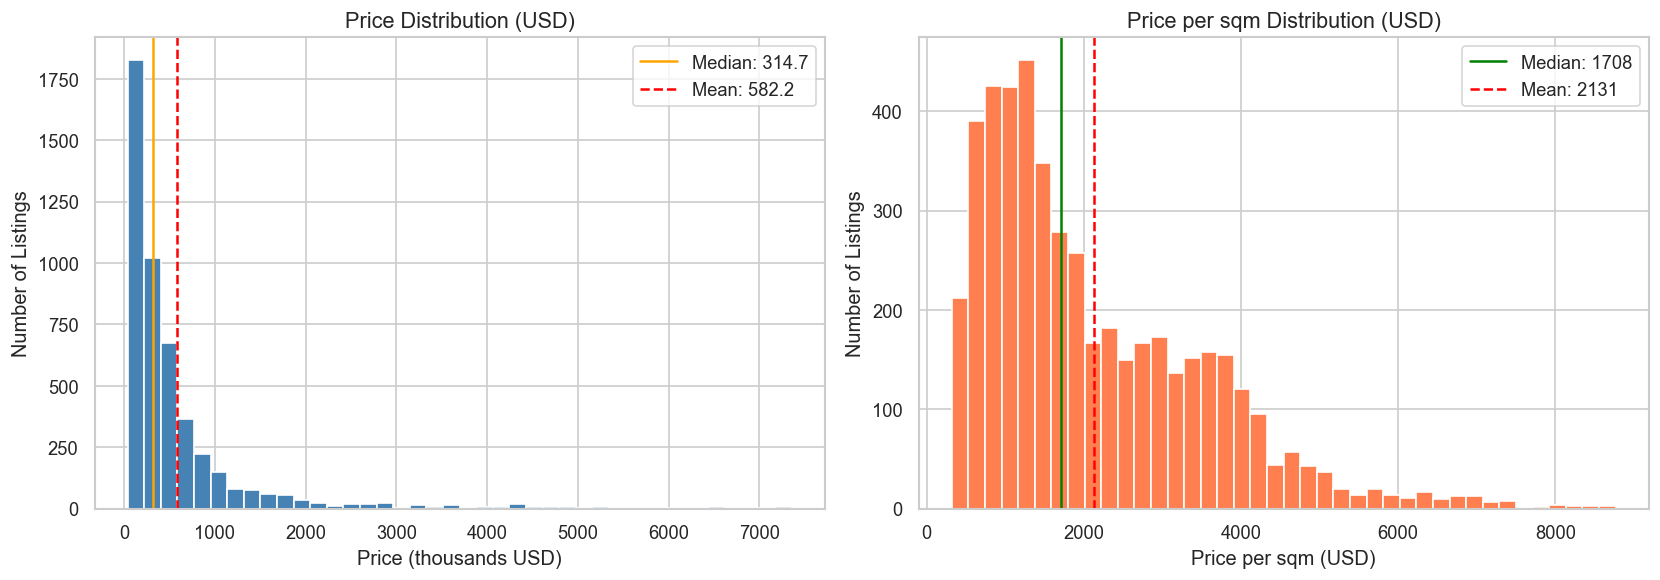

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total price histogram
prices_m = df_clean['price_usd'] / 1000  # thousands USD
axes[0].hist(prices_m, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(prices_m.median(), color='orange', linestyle='-', label=f'Median: {prices_m.median():.1f}')
axes[0].axvline(prices_m.mean(), color='red', linestyle='--', label=f'Mean: {prices_m.mean():.1f}')
axes[0].set_title('Price Distribution (USD)', fontsize=13)
axes[0].set_xlabel('Price (thousands USD)')
axes[0].set_ylabel('Number of Listings')
axes[0].legend()

# Price per sqm histogram
sqm_price = df_clean['price_per_unit_usd']
axes[1].hist(sqm_price, bins=40, color='coral', edgecolor='white')
axes[1].axvline(sqm_price.median(), color='green', linestyle='-', label=f'Median: {sqm_price.median():.0f}')
axes[1].axvline(sqm_price.mean(), color='red', linestyle='--', label=f'Mean: {sqm_price.mean():.0f}')
axes[1].set_title('Price per sqm Distribution (USD)', fontsize=13)
axes[1].set_xlabel('Price per sqm (USD)')
axes[1].set_ylabel('Number of Listings')
axes[1].legend()

plt.tight_layout()
plt.savefig('../visuals/price_distribution.png', bbox_inches='tight')

### 5.2 Price per sqm by District

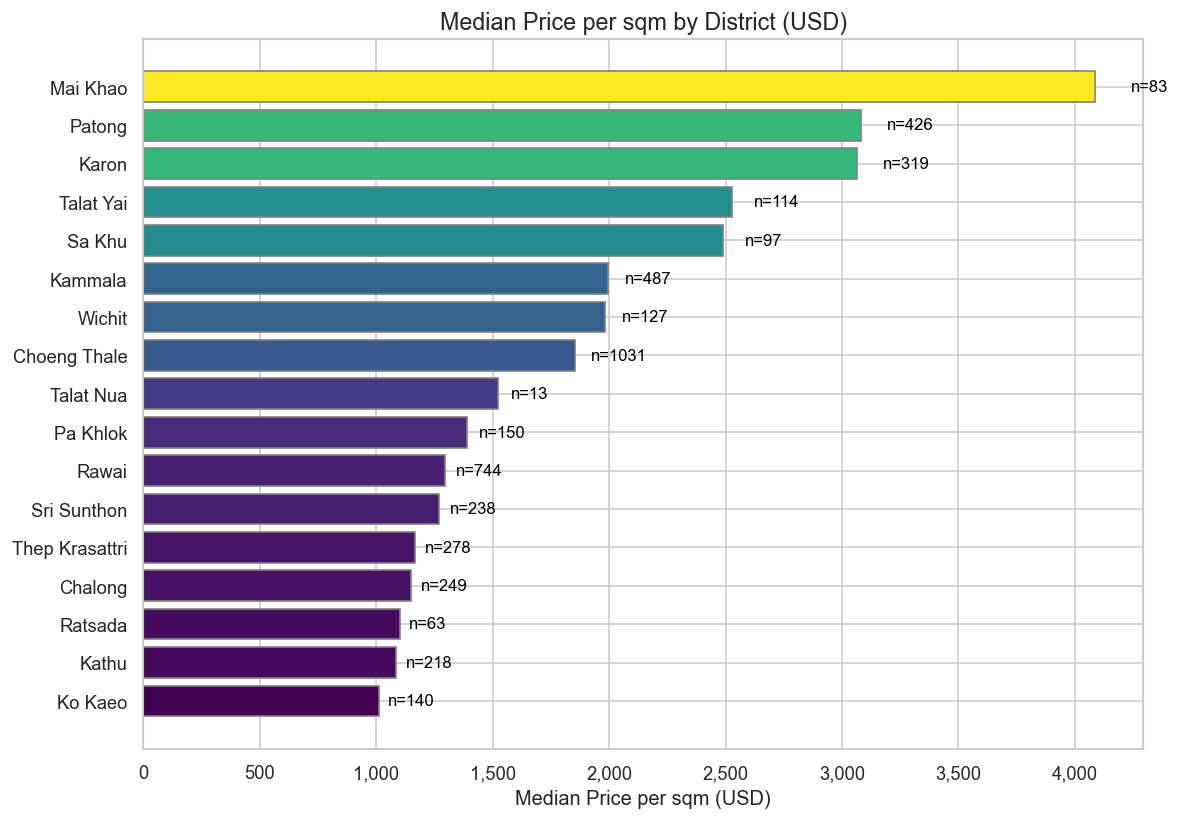

In [20]:
area_col = 'district'

area_stats = (
    df_clean.groupby(area_col)['price_per_unit_usd']
    .agg(['median', 'count'])
    .rename(columns={'median': 'median_price_sqm', 'count': 'listings'})
    .query('listings >= 10')  # only districts with enough data
    .sort_values('median_price_sqm', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))
# Gradient bar coloring
cmap = cm.get_cmap('viridis')
norm = plt.Normalize(area_stats['median_price_sqm'].min(), area_stats['median_price_sqm'].max())
colors = cmap(norm(area_stats['median_price_sqm']))
bars = ax.barh(area_stats.index, area_stats['median_price_sqm'], color=colors, edgecolor='gray')
ax.set_title('Median Price per sqm by District (USD)', fontsize=14)
ax.set_xlabel('Median Price per sqm (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Annotate bars with listing counts
for bar, count in zip(bars, area_stats['listings']):
    ax.text(bar.get_width() * 1.0369, bar.get_y() + bar.get_height()/2,
            f'n={count}', va='center', fontsize=10, color='black')


plt.tight_layout()
plt.savefig('../visuals/price_by_area.png', bbox_inches='tight')

### 5.3 Price by Property Type

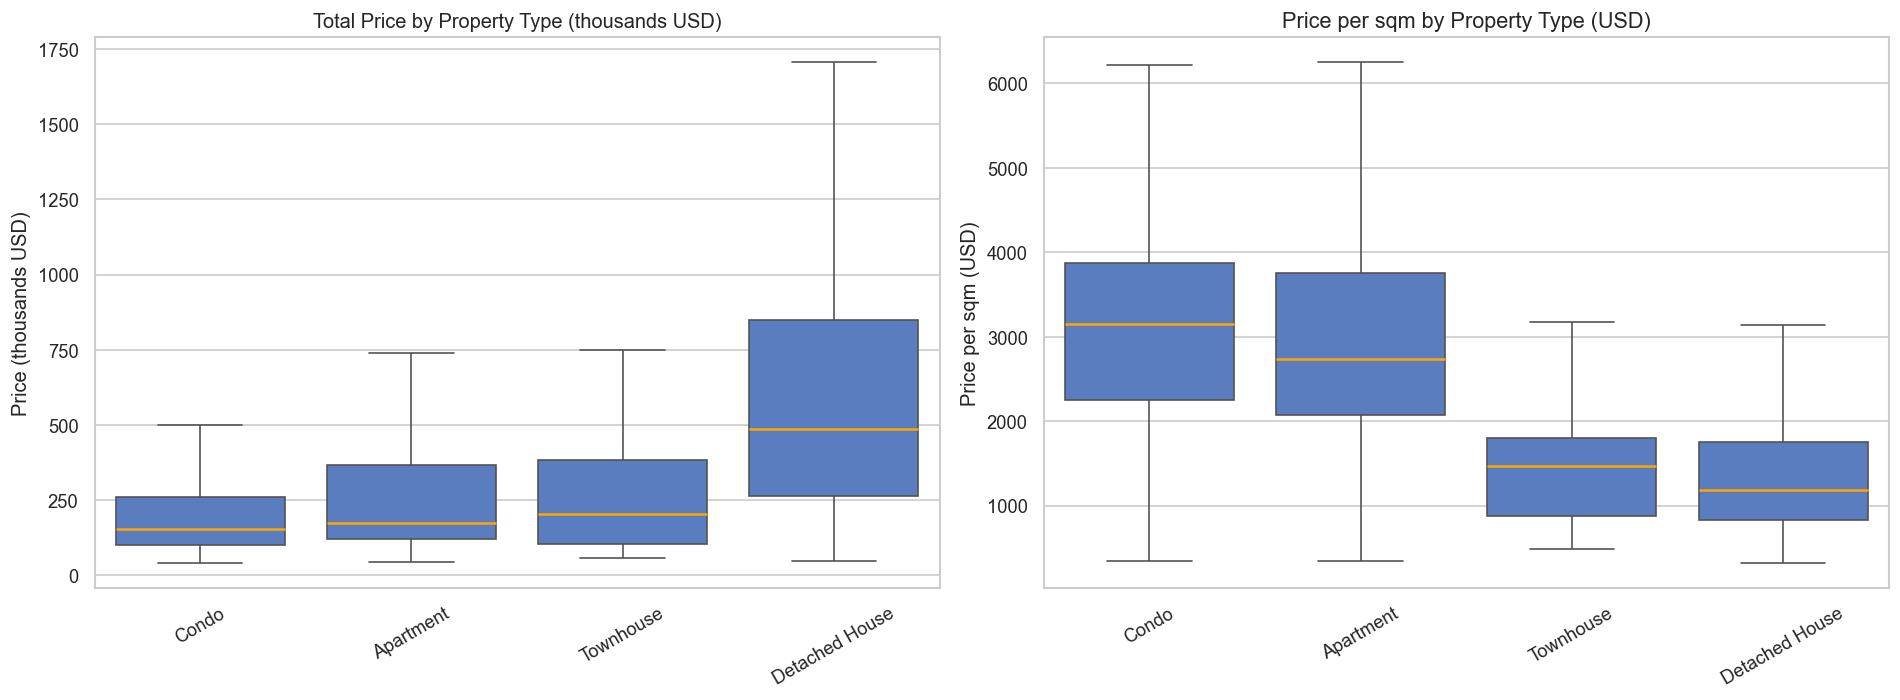

In [21]:
type_col = 'property_type'

type_order = df_clean.groupby(type_col)['price_usd'].median().sort_values().index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
m_props = {'color': 'orange', 'linewidth': 1.5}

# Total price by type
sns.boxplot(data=df_clean, x=type_col, y=df_clean['price_usd'] / 1000, order=type_order,
            showfliers=False, ax=axes[0], medianprops=m_props)
axes[0].set_title('Total Price by Property Type (thousands USD)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Price (thousands USD)')
axes[0].tick_params(axis='x', rotation=30)

# Price per sqm by type
sns.boxplot(data=df_clean, x=type_col, y='price_per_unit_usd', order=type_order,
            showfliers=False, ax=axes[1], medianprops=m_props)
axes[1].set_title('Price per sqm by Property Type (USD)', fontsize=13)
axes[1].set_xlabel('')
axes[1].set_ylabel('Price per sqm (USD)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../visuals/price_by_type.png', bbox_inches='tight')

### 5.4 Listings Count by District

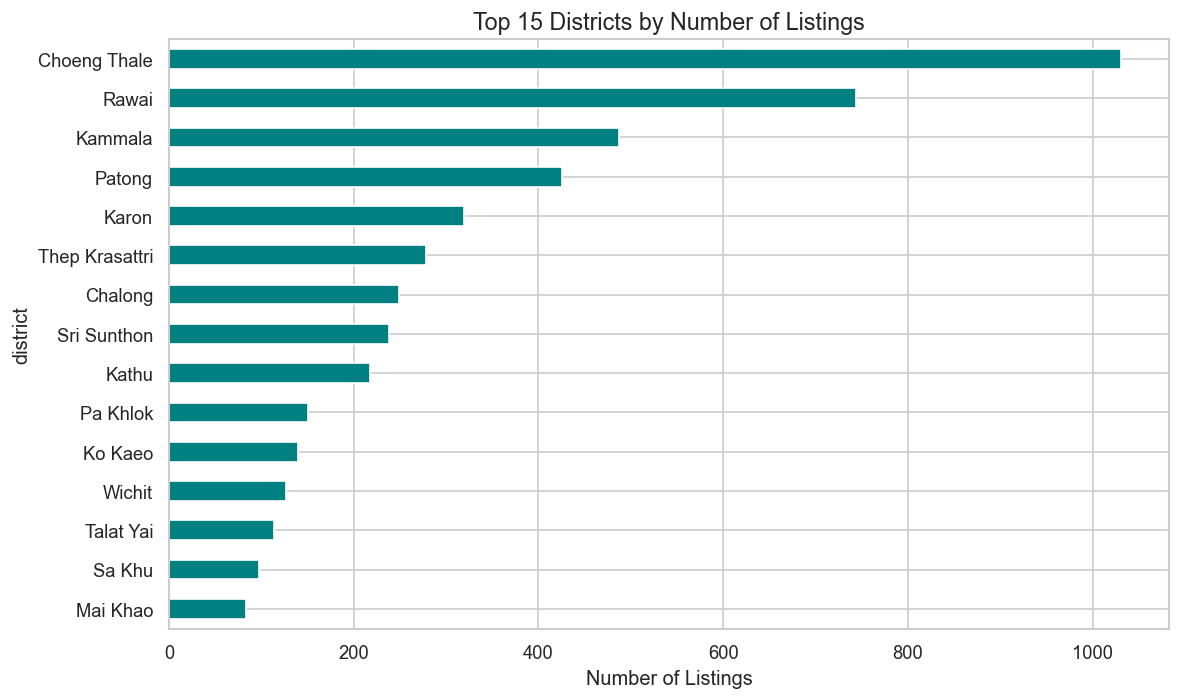

In [22]:
listing_counts = df_clean[area_col].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
listing_counts.sort_values().plot(kind='barh', ax=ax, color='teal')
ax.set_title('Top 15 Districts by Number of Listings', fontsize=14)
ax.set_xlabel('Number of Listings')

plt.tight_layout()
plt.savefig('../visuals/listings_by_area.png', bbox_inches='tight')

### 5.5 Size vs. Price

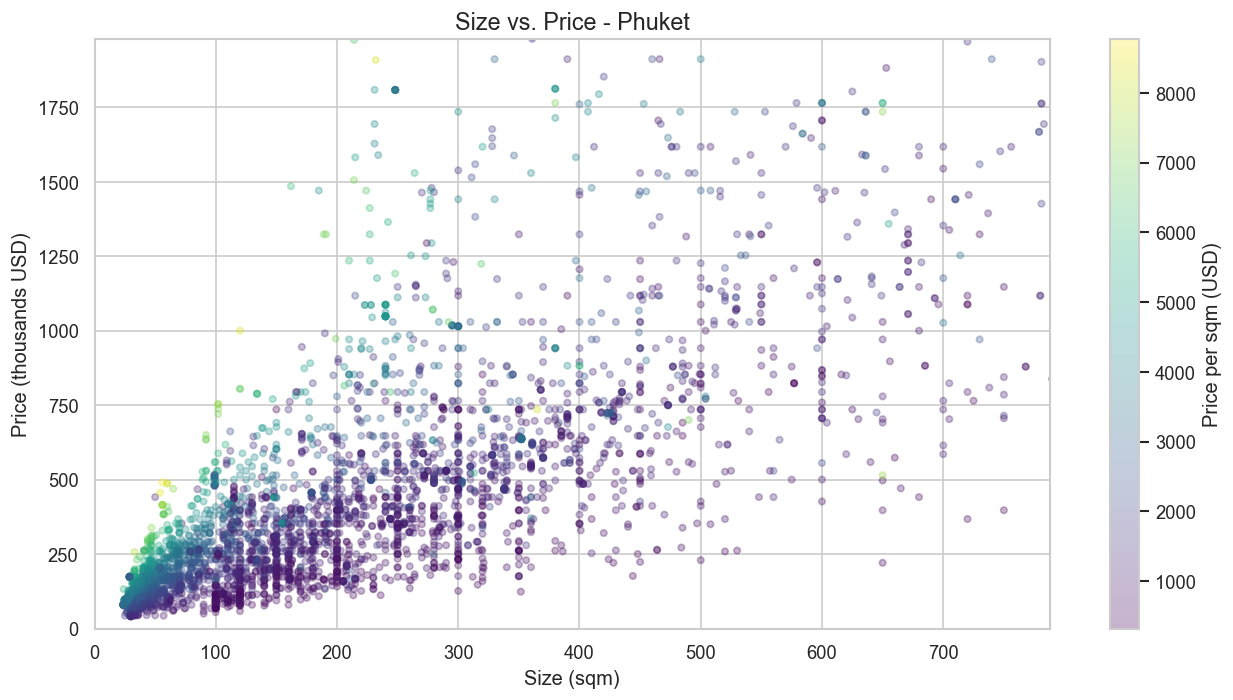

In [23]:
fig, ax = plt.subplots(figsize=(11, 6))

scatter = ax.scatter(
    df_clean['living_space'],
    df_clean['price_usd'] / 1000,  # in thousands USD
    alpha=0.3,
    c=df_clean['price_per_unit_usd'],
    cmap='viridis',
    s=15
)

plt.colorbar(scatter, ax=ax, label='Price per sqm (USD)')
ax.set_title('Size vs. Price - Phuket', fontsize=14)
ax.set_xlabel('Size (sqm)')
ax.set_ylabel('Price (thousands USD)')

# Zoom into 95% of data, ignore extreme outliers
ax.set_xlim(0, df_clean['living_space'].quantile(0.95))
ax.set_ylim(0, (df_clean['price_usd'] / 1000).quantile(0.95))

plt.tight_layout()
plt.savefig('../visuals/size_vs_price.png', bbox_inches='tight')

### 5.6 Furnished Status

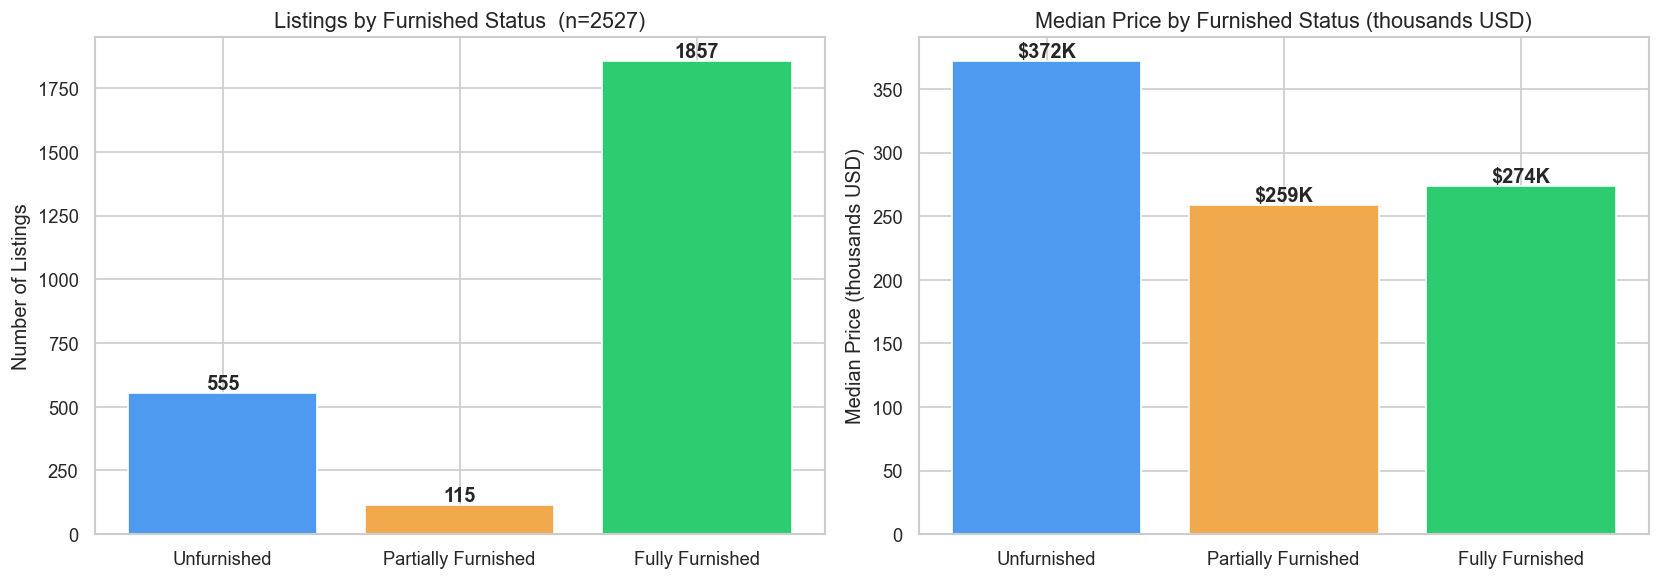

In [24]:
furnished_order = ['Unfurnished', 'Partially Furnished', 'Fully Furnished']
df_furn = df_clean.dropna(subset=['furnished'])
n_furn = len(df_furn)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4e9af1', '#f1a94e', '#2ecc71']

# Listing count by furnished status
counts = df_furn['furnished'].value_counts().reindex(furnished_order)
axes[0].bar(furnished_order, counts.values, color=colors)
axes[0].set_title(f'Listings by Furnished Status  (n={n_furn})', fontsize=13)
axes[0].set_ylabel('Number of Listings')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 15, str(v), ha='center', fontweight='bold')

# Median price by furnished status
medians = df_furn.groupby('furnished')['price_usd'].median().reindex(furnished_order) / 1_000
axes[1].bar(furnished_order, medians.values, color=colors)
axes[1].set_title('Median Price by Furnished Status (thousands USD)', fontsize=13)
axes[1].set_ylabel('Median Price (thousands USD)')
for i, v in enumerate(medians.values):
    axes[1].text(i, v + 3, f'${v:.0f}K', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../visuals/furnished_analysis.png', bbox_inches='tight')
plt.show()

### 5.7 Premium vs Standard

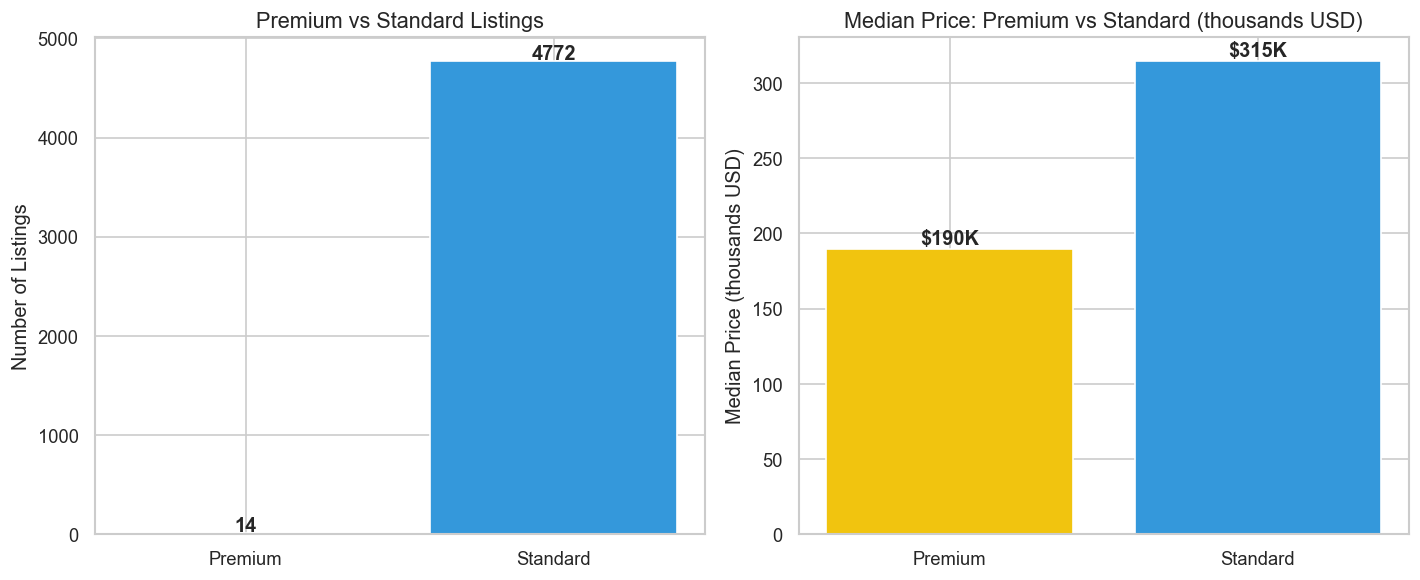

In [25]:
df_clean['premium_label'] = df_clean['premium'].map({1: 'Premium', 0: 'Standard'})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#f1c40f', '#3498db']

# Count
counts = df_clean['premium_label'].value_counts().reindex(['Premium', 'Standard'])
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title('Premium vs Standard Listings', fontsize=13)
axes[0].set_ylabel('Number of Listings')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 15, str(v), ha='center', fontweight='bold')

# Median price
medians = df_clean.groupby('premium_label')['price_usd'].median().reindex(['Premium', 'Standard']) / 1000
axes[1].bar(medians.index, medians.values, color=colors)
axes[1].set_title('Median Price: Premium vs Standard (thousands USD)', fontsize=13)
axes[1].set_ylabel('Median Price (thousands USD)')
for i, v in enumerate(medians.values):
    axes[1].text(i, v + 3, f'${v:.0f}K', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../visuals/premium_analysis.png', bbox_inches='tight')
plt.show()

### 5.8 Tenure Type (Freehold vs Leasehold)

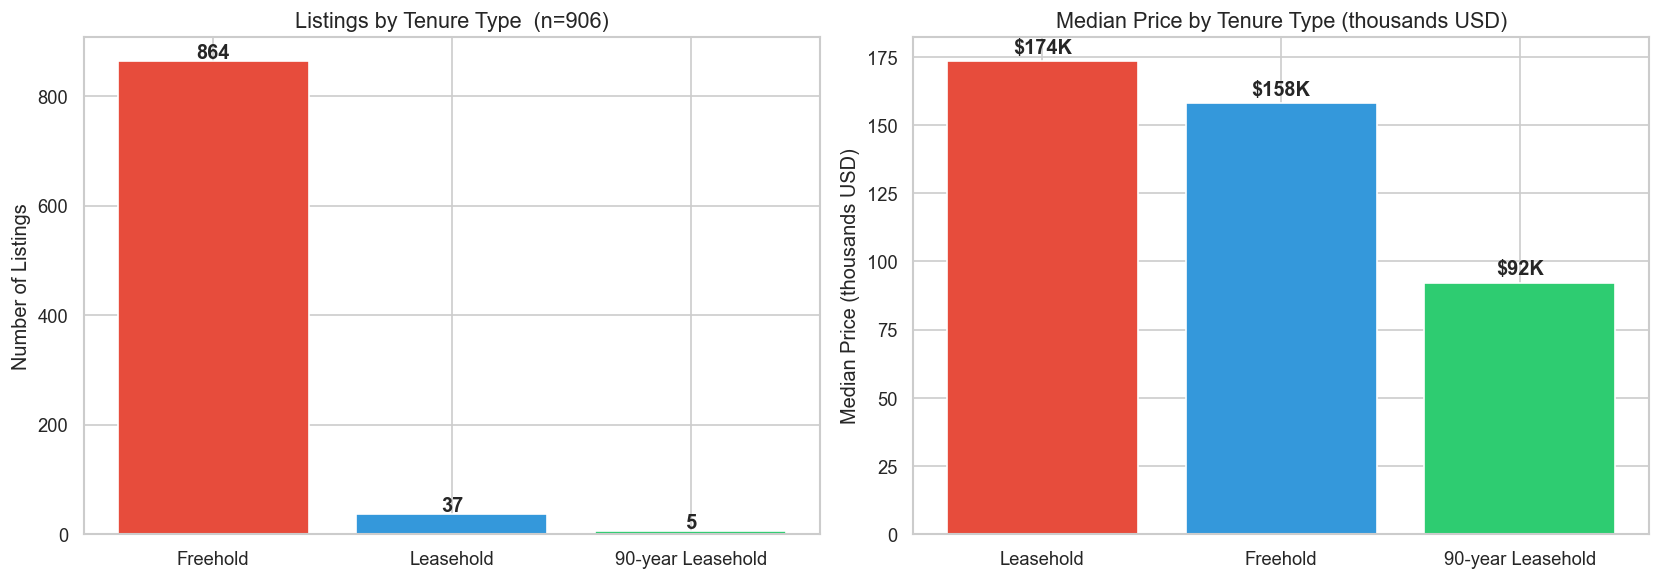

In [26]:
df_tenure = df_clean.dropna(subset=['tenure'])
n_tenure = len(df_tenure)

tenure_counts = df_tenure['tenure'].value_counts()
tenure_medians = df_tenure.groupby('tenure')['price_usd'].median().sort_values(ascending=False) / 1_000

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71']

# Count by tenure
axes[0].bar(tenure_counts.index, tenure_counts.values, color=colors)
axes[0].set_title(f'Listings by Tenure Type  (n={n_tenure})', fontsize=13)
axes[0].set_ylabel('Number of Listings')
for i, v in enumerate(tenure_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Median price by tenure
axes[1].bar(tenure_medians.index, tenure_medians.values, color=colors)
axes[1].set_title('Median Price by Tenure Type (thousands USD)', fontsize=13)
axes[1].set_ylabel('Median Price (thousands USD)')
for i, v in enumerate(tenure_medians.values):
    axes[1].text(i, v + 3, f'${v:.0f}K', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../visuals/tenure_analysis.png', bbox_inches='tight')
plt.show()

### 5.9 Land Space vs Price (Houses & Townhouses)

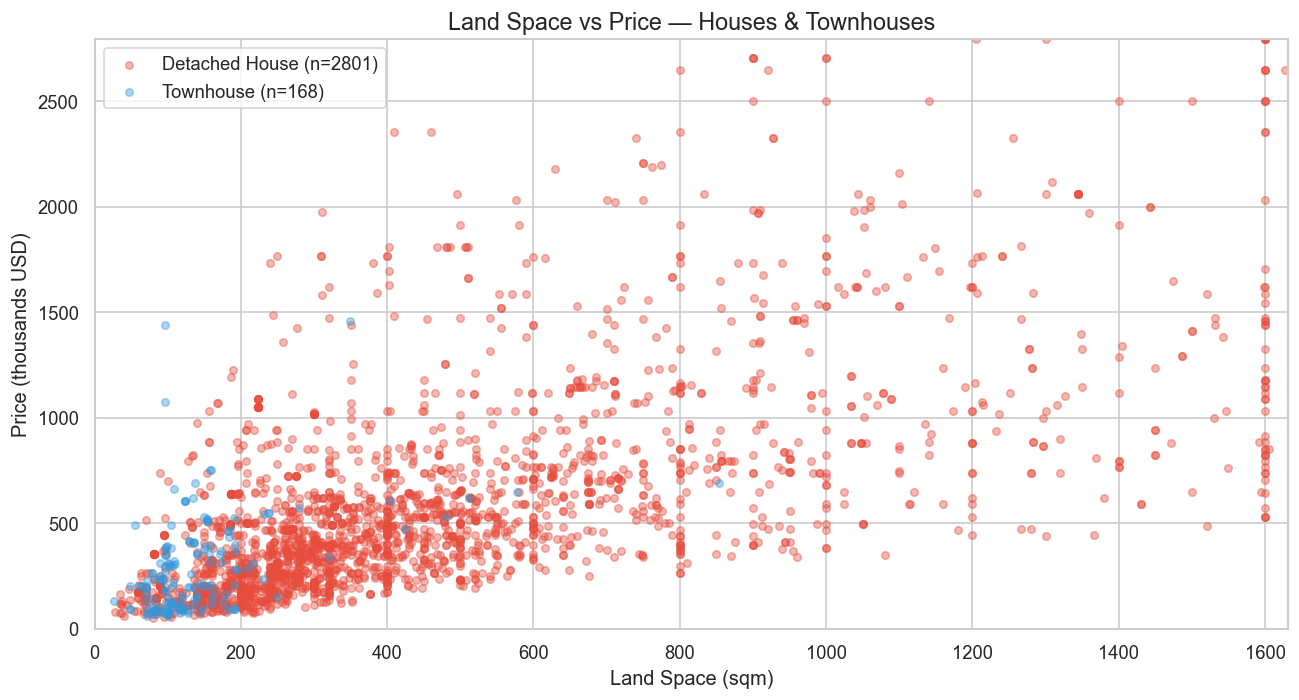

In [27]:
df_land = df_clean.dropna(subset=['land_space'])
df_land = df_land[df_land['property_type'].isin(['Detached House', 'Townhouse'])]

fig, ax = plt.subplots(figsize=(11, 6))
palette = {'Detached House': '#e74c3c', 'Townhouse': '#3498db'}

for ptype, color in palette.items():
    subset = df_land[df_land['property_type'] == ptype]
    ax.scatter(subset['land_space'], subset['price_usd'] / 1000,
               alpha=0.4, label=f'{ptype} (n={len(subset)})',
               color=color, s=20)

# Zoom into 95% to ignore extreme outliers
ax.set_xlim(0, df_land['land_space'].quantile(0.95))
ax.set_ylim(0, df_land['price_usd'].quantile(0.95) / 1000)

ax.set_title('Land Space vs Price — Houses & Townhouses', fontsize=14)
ax.set_xlabel('Land Space (sqm)')
ax.set_ylabel('Price (thousands USD)')
ax.legend()

plt.tight_layout()
plt.savefig('../visuals/land_space_analysis.png', bbox_inches='tight')
plt.show()

### 5.10 Median Price by Year Built

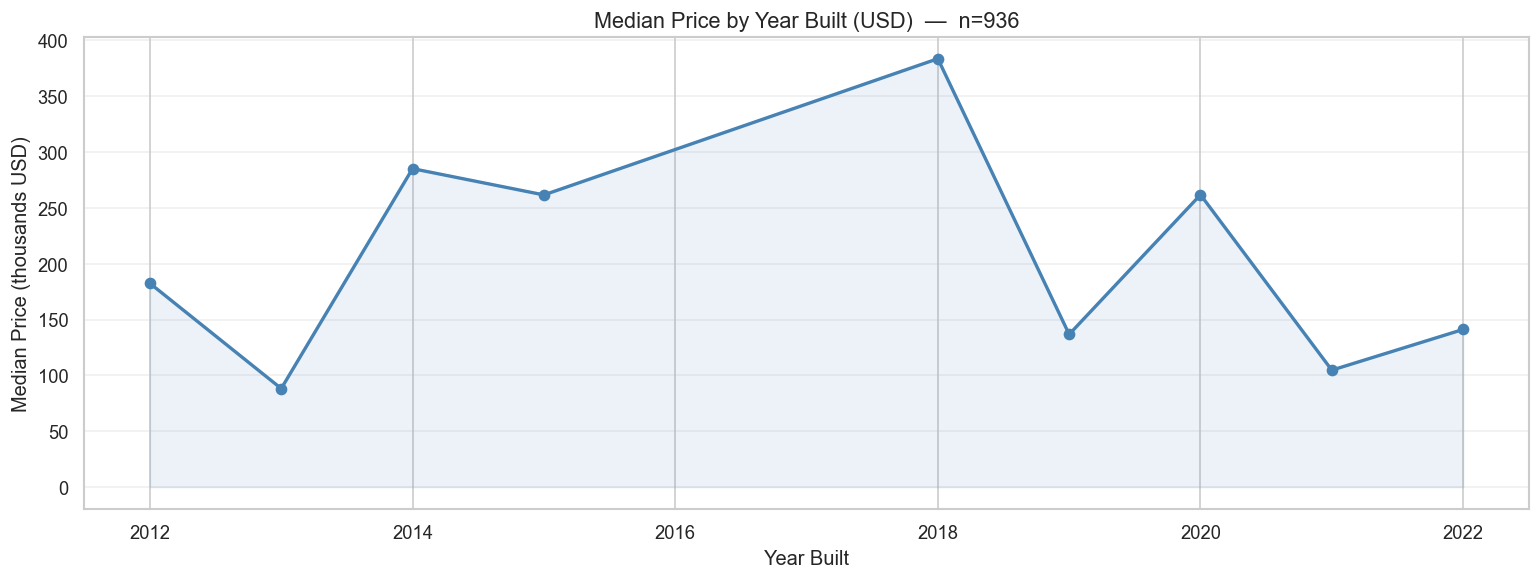

In [28]:
df_year = df_clean.dropna(subset=['built_year'])
n_year = len(df_year)

year_stats = (
    df_year.groupby('built_year')['price_usd']
    .agg(['median', 'count'])
    .query('count >= 5')  # only years with enough data
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(year_stats['built_year'], year_stats['median'] / 1_000,
        marker='o', color='steelblue', linewidth=2, markersize=6)

ax.fill_between(year_stats['built_year'], year_stats['median'] / 1_000,
                alpha=0.1, color='steelblue')

ax.set_title(f'Median Price by Year Built (USD)  —  n={n_year}', fontsize=13)
ax.set_xlabel('Year Built')
ax.set_ylabel('Median Price (thousands USD)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../visuals/year_built_analysis.png', bbox_inches='tight')
plt.show()

### 5.11 Geographic Heatmap

Plot every listing on its actual coordinates. Static PNG for GitHub preview; interactive HTML (folium) saved separately so you can zoom into clusters.

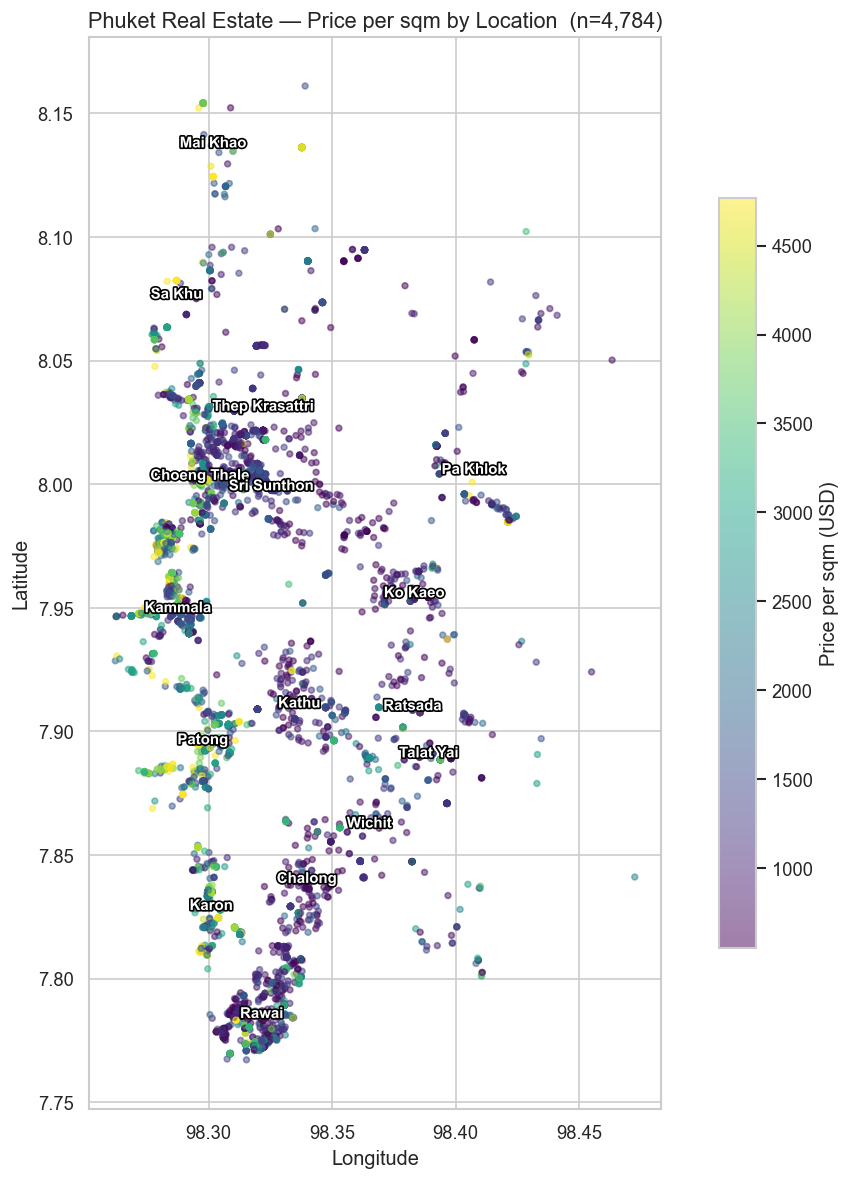

In [39]:
import folium
from folium.plugins import HeatMap
from matplotlib.patheffects import withStroke

# Use only listings that have valid coordinates
df_geo = df_clean.dropna(subset=['latitude', 'longitude']).copy()

# ── Static matplotlib map for README / GitHub preview ───────────────
fig, ax = plt.subplots(figsize=(10, 10))
sc = ax.scatter(
    df_geo['longitude'], df_geo['latitude'],
    c=df_geo['price_per_unit_usd'],
    cmap='viridis', alpha=0.5, s=12,
    vmin=df_geo['price_per_unit_usd'].quantile(0.05),
    vmax=df_geo['price_per_unit_usd'].quantile(0.95),
)
cb = plt.colorbar(sc, ax=ax, shrink=0.7)
cb.set_label('Price per sqm (USD)')

# Label district centroids — only districts with enough listings to be meaningful
centroids = (
    df_geo.groupby('district')[['latitude','longitude']].median()
    .join(df_geo['district'].value_counts().rename('n'))
    .query('n >= 30')
)
for d, row in centroids.iterrows():
    ax.text(row['longitude'], row['latitude'], d,
            fontsize=9, fontweight='bold', ha='center', color='white',
            path_effects=[withStroke(linewidth=2, foreground='black')])

ax.set_title(f'Phuket Real Estate — Price per sqm by Location  (n={len(df_geo):,})', fontsize=13)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('../visuals/price_map.png', bbox_inches='tight', dpi=110)
plt.show()

# ── Interactive folium map (saved as HTML) ──────────────────────────
center = [df_geo['latitude'].median(), df_geo['longitude'].median()]
m = folium.Map(location=center, zoom_start=11, tiles='CartoDB positron')

# Heatmap weighted by price/sqm — normalize so the gradient is meaningful
weights = df_geo['price_per_unit_usd'] / df_geo['price_per_unit_usd'].max()
heat_data = list(zip(df_geo['latitude'], df_geo['longitude'], weights))
HeatMap(heat_data, radius=10, blur=15, min_opacity=0.3).add_to(m)

# Add markers for the 5 most expensive listings, with popups
top5 = df_geo.nlargest(5, 'price_usd')
for _, r in top5.iterrows():
    folium.Marker(
        [r['latitude'], r['longitude']],
        popup=(f"<b>{r['property_type']}</b><br>"
               f"District: {r['district']}<br>"
               f"Size: {r['living_space']:.0f} sqm<br>"
               f"Price: ${r['price_usd']:,.0f}<br>"
               f"$/sqm: ${r['price_per_unit_usd']:,.0f}"),
        icon=folium.Icon(color='red', icon='home'),
    ).add_to(m)

m.save('../visuals/phuket_map.html')

## 6. Statistical Analysis

### 6.1 Feature Correlation

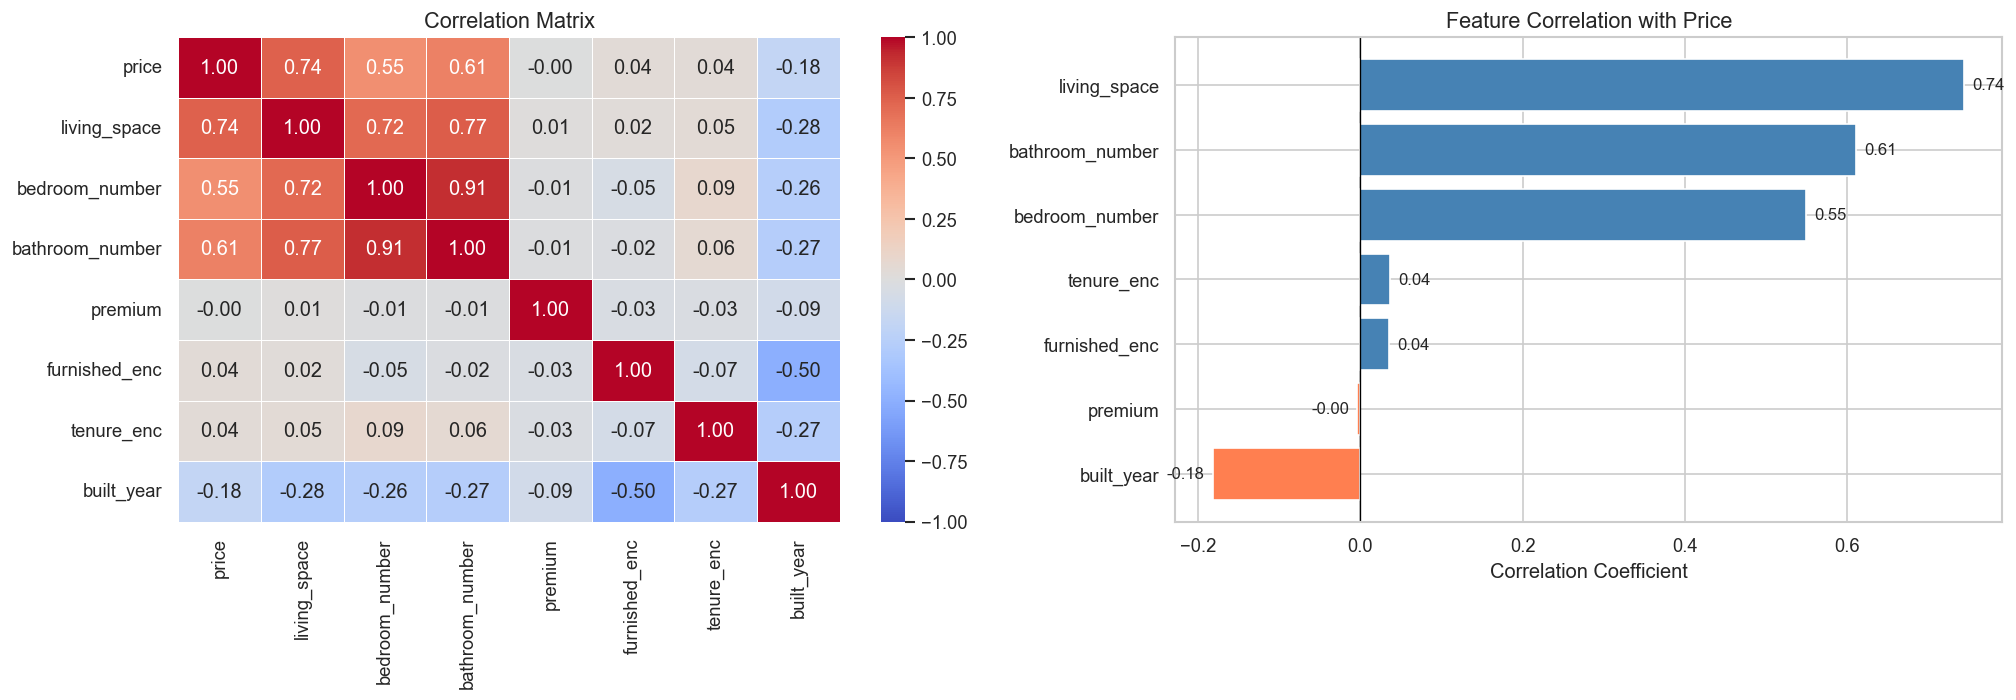

In [30]:
# Encode categorical features for correlation
furnished_map = {'Unfurnished': 0, 'Partially Furnished': 1, 'Fully Furnished': 2}
tenure_map    = {'Leasehold': 0, '90-year Leasehold': 1, 'Freehold': 2}

df_corr = df_clean.copy()
df_corr['furnished_enc'] = df_corr['furnished'].map(furnished_map)
df_corr['tenure_enc']    = df_corr['tenure'].map(tenure_map)

features = [
    'price', 'living_space', 'bedroom_number',
    'bathroom_number', 'premium', 'furnished_enc',
    'tenure_enc', 'built_year'
    ]

corr_df = df_corr[features].corr()

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Correlation heatmap
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[0], linewidths=0.5, vmin=-1, vmax=1)
axes[0].set_title('Correlation Matrix', fontsize=13)

# Feature correlation with price (sorted)
price_corr = (
    corr_df['price']
    .drop('price')
    .sort_values()
)
colors = ['coral' if v < 0 else 'steelblue' for v in price_corr]
axes[1].barh(price_corr.index, price_corr.values, color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Correlation with Price', fontsize=13)
axes[1].set_xlabel('Correlation Coefficient')
for i, v in enumerate(price_corr.values):
    axes[1].text(v + 0.01 if v >= 0 else v - 0.01, i,
                 f'{v:.2f}', va='center',
                 ha='left' if v >= 0 else 'right', fontsize=10)

plt.tight_layout()
plt.savefig('../visuals/feature_correlation.png', bbox_inches='tight')
plt.show()

### 6.2 District Price Difference (Mann-Whitney U Test)

The price/sqm gap between districts looks huge (Patong $3,080 vs Kathu $1,086 — almost 3×), but is the difference *statistically real* or just noise? Use the Mann-Whitney U test — non-parametric, robust to the skewed price distribution.

In [31]:
from scipy.stats import mannwhitneyu

# Compare price/sqm distributions for the most expensive and most affordable districts.
# Mann-Whitney U is non-parametric — doesn't assume normality (which our skewed prices
# violate badly), and works on medians/ranks instead of means.
pairs = [
    ('Patong',   'Kathu'),    # most-expensive coastal vs cheap inland
    ('Mai Khao', 'Ko Kaeo'),  # extreme top vs extreme bottom
    ('Patong',   'Karon'),    # two neighbouring premium districts (sanity check)
]

def cliffs_delta(x, y):
    """Effect size for Mann-Whitney. |delta|: 0.147=small, 0.33=medium, 0.474=large."""
    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    gt = (x[:, None] > y[None, :]).sum()
    lt = (x[:, None] < y[None, :]).sum()
    return (gt - lt) / (len(x) * len(y))

print(f"{'Comparison':<25} {'n1':>5} {'n2':>5} {'med1':>9} {'med2':>9}  {'p-value':<12} {'Cliff δ':>8} verdict")
print('-' * 95)
for a, b in pairs:
    x = df_clean.loc[df_clean['district'] == a, 'price_per_unit_usd']
    y = df_clean.loc[df_clean['district'] == b, 'price_per_unit_usd']
    if len(x) < 5 or len(y) < 5:
        continue
    stat, p = mannwhitneyu(x, y, alternative='two-sided')
    delta = cliffs_delta(x, y)
    sig = 'significant' if p < 0.05 else 'not significant'
    size = 'large' if abs(delta) > 0.474 else 'medium' if abs(delta) > 0.33 else 'small' if abs(delta) > 0.147 else 'negligible'
    print(f'{a + " vs " + b:<25} {len(x):>5} {len(y):>5} ${x.median():>7,.0f} ${y.median():>7,.0f}  {p:<12.2e} {delta:>+8.3f} {sig}, {size}')

print('\nInterpretation:')
print('  • p < 0.05 means we reject the null hypothesis "distributions are the same".')
print('  • The Patong vs Karon comparison is a sanity check — both are premium beach districts,')
print('    so we expect a smaller effect size than Patong vs Kathu.')

Comparison                   n1    n2      med1      med2  p-value       Cliff δ verdict
-----------------------------------------------------------------------------------------------
Patong vs Kathu             426   218 $  3,080 $  1,086  1.08e-58       +0.777 significant, large
Mai Khao vs Ko Kaeo          83   140 $  4,088 $  1,012  2.37e-23       +0.798 significant, large
Patong vs Karon             426   319 $  3,080 $  3,063  5.53e-01       +0.025 not significant, negligible

Interpretation:
  • p < 0.05 means we reject the null hypothesis "distributions are the same".
  • The Patong vs Karon comparison is a sanity check — both are premium beach districts,
    so we expect a smaller effect size than Patong vs Kathu.


## 7. Price Prediction Model

Using the features we analyzed to build a model that predicts property price.
We compare two models: **Linear Regression** (baseline) and **Random Forest** (advanced).

In [32]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

df_ml = df_clean.copy()

# Keep categorical missings as their own category — preserves ~88% of the data
# that would otherwise be dropped because tenure is 80% NaN and furnished 47% NaN.
df_ml['furnished'] = df_ml['furnished'].fillna('Unknown')
df_ml['tenure']    = df_ml['tenure'].fillna('Unknown')

# Numeric imputation: living_space ← land_space (for house listings), then median
df_ml['living_space']    = df_ml['living_space'].fillna(df_ml['land_space'])
df_ml['living_space']    = df_ml['living_space'].clip(upper=df_ml['living_space'].quantile(0.99))
df_ml['living_space']    = df_ml['living_space'].fillna(df_ml['living_space'].median())
df_ml['bedroom_number']  = df_ml['bedroom_number'].fillna(df_ml['bedroom_number'].median())
df_ml['bathroom_number'] = df_ml['bathroom_number'].fillna(df_ml['bathroom_number'].median())

numeric_features     = ['living_space', 'bedroom_number', 'bathroom_number', 'premium']
categorical_features = ['district', 'property_type', 'furnished', 'tenure']

X = df_ml[numeric_features + categorical_features]
y = df_ml['price_usd'].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# One-hot for categoricals, scaling for numerics — same preprocessor for both models
preprocessor = ColumnTransformer([
    ('num', StandardScaler(),                    numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
])

print(f'Training samples: {len(X_train):,}')
print(f'Test samples:     {len(X_test):,}')
print(f'Numeric features:    {numeric_features}')
print(f'Categorical features: {categorical_features}')

Training samples: 3,828
Test samples:     958
Numeric features:    ['living_space', 'bedroom_number', 'bathroom_number', 'premium']
Categorical features: ['district', 'property_type', 'furnished', 'tenure']


### 7.1 Linear Regression (Baseline)

In [33]:
lr_pipe = Pipeline([
    ('prep', preprocessor),
    ('lr',   LinearRegression()),
])
lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr  = r2_score(y_test, y_pred_lr)

# 5-fold CV for a more robust R² estimate
cv_lr = cross_val_score(lr_pipe, X, y, cv=5, scoring='r2', n_jobs=-1)

print('── Linear Regression ──')
print(f'R²  (hold-out): {r2_lr:.3f}')
print(f'R²  (5-fold CV): {cv_lr.mean():.3f} ± {cv_lr.std():.3f}')
print(f'MAE : ${mae_lr:,.0f}')

── Linear Regression ──
R²  (hold-out): 0.540
R²  (5-fold CV): 0.569 ± 0.038
MAE : $285,969


### 7.2 Random Forest

In [34]:
rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('rf',   RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)),
])
rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf  = r2_score(y_test, y_pred_rf)

cv_rf = cross_val_score(rf_pipe, X, y, cv=5, scoring='r2', n_jobs=-1)

print('── Random Forest ──')
print(f'R²  (hold-out): {r2_rf:.3f}')
print(f'R²  (5-fold CV): {cv_rf.mean():.3f} ± {cv_rf.std():.3f}')
print(f'MAE : ${mae_rf:,.0f}')

── Random Forest ──
R²  (hold-out): 0.689
R²  (5-fold CV): 0.655 ± 0.046
MAE : $182,094


### 7.3 Hyperparameter Tuning (GridSearchCV)

The default `n_estimators=300` was picked arbitrarily. `GridSearchCV` searches a grid of parameter combinations using 5-fold cross-validation and picks the best by R². The tuned model (`rf_best`) is used downstream for feature importance and predictions.

In [35]:
from sklearn.model_selection import GridSearchCV
import time

# Grid kept small (8 combos × 5 folds = 40 fits, ~100s on a laptop).
# Larger grids would search more thoroughly but for a portfolio project
# this already demonstrates the methodology.
param_grid = {
    'rf__n_estimators':      [200, 400],
    'rf__max_depth':         [None, 15],
    'rf__min_samples_leaf':  [1, 2],
}

gs = GridSearchCV(rf_pipe, param_grid, cv=5, scoring='r2', n_jobs=-1)
t0 = time.time()
gs.fit(X_train, y_train)
elapsed = time.time() - t0

rf_best = gs.best_estimator_
y_pred_best = rf_best.predict(X_test)
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best  = r2_score(y_test, y_pred_best)

print(f'GridSearchCV finished in {elapsed:.0f}s ({len(gs.cv_results_["params"])} combinations × 5 folds)')
print(f'\nBest params:')
for k, v in gs.best_params_.items():
    print(f'  {k:30s} = {v}')
print(f'\nBest CV R² : {gs.best_score_:.3f}  (untuned: {cv_rf.mean():.3f})')
print(f'Hold-out R²: {r2_best:.3f}')
print(f'Hold-out MAE: ${mae_best:,.0f}')

GridSearchCV finished in 87s (8 combinations × 5 folds)

Best params:
  rf__max_depth                  = 15
  rf__min_samples_leaf           = 1
  rf__n_estimators               = 200

Best CV R² : 0.706  (untuned: 0.655)
Hold-out R²: 0.687
Hold-out MAE: $186,640


### 7.4 Model Comparison & Feature Importance

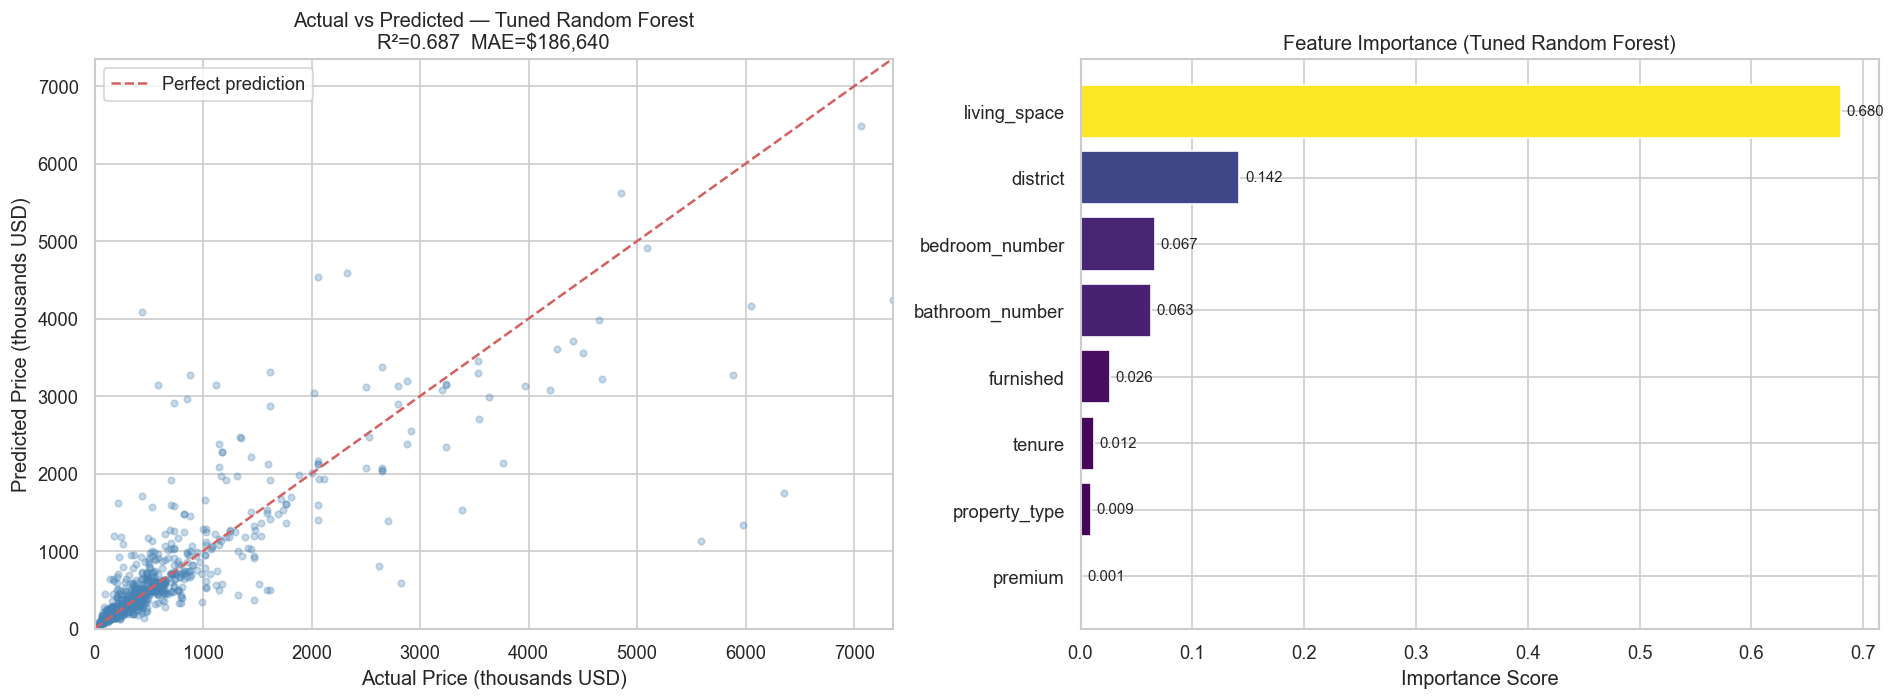

── Model Comparison ──
Linear Regression       → R²: 0.540 | CV: 0.569 ± 0.038 | MAE: $285,969
Random Forest (default) → R²: 0.689 | CV: 0.655 ± 0.046 | MAE: $182,094
Random Forest (tuned)   → R²: 0.687 | CV: 0.706              | MAE: $186,640


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: Actual vs Predicted (tuned Random Forest) ──
axes[0].scatter(y_test / 1_000, y_pred_best / 1_000,
                alpha=0.3, s=15, color='steelblue')
max_val = max(y_test.max(), y_pred_best.max()) / 1_000
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlim(0, max_val)
axes[0].set_ylim(0, max_val)
axes[0].set_title(f'Actual vs Predicted — Tuned Random Forest\nR²={r2_best:.3f}  MAE=${mae_best:,.0f}', fontsize=12)
axes[0].set_xlabel('Actual Price (thousands USD)')
axes[0].set_ylabel('Predicted Price (thousands USD)')
axes[0].legend()

# ── Right: Feature Importance (from tuned model) ──
# One-hot expands `district` into 19 columns etc.; aggregate them back to base features
# so importance reflects the original feature, not individual category levels.
rf_model  = rf_best.named_steps['rf']
ohe_names = rf_best.named_steps['prep'].get_feature_names_out()

def base_feature(col_name):
    if col_name.startswith('num__'):
        return col_name[len('num__'):]
    if col_name.startswith('cat__'):
        rest = col_name[len('cat__'):]
        for feat in categorical_features:
            if rest.startswith(feat + '_'):
                return feat
    return col_name

agg = {}
for name, val in zip(ohe_names, rf_model.feature_importances_):
    b = base_feature(name)
    agg[b] = agg.get(b, 0.0) + val
importance = pd.Series(agg).sort_values()

colors = plt.cm.viridis([v / importance.max() for v in importance.values])
axes[1].barh(importance.index, importance.values, color=colors)
axes[1].set_title('Feature Importance (Tuned Random Forest)', fontsize=12)
axes[1].set_xlabel('Importance Score')
for i, v in enumerate(importance.values):
    axes[1].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../visuals/model_results.png', bbox_inches='tight')
plt.show()

# Side-by-side comparison of all three models
print('── Model Comparison ──')
print(f'Linear Regression       → R²: {r2_lr:.3f} | CV: {cv_lr.mean():.3f} ± {cv_lr.std():.3f} | MAE: ${mae_lr:,.0f}')
print(f'Random Forest (default) → R²: {r2_rf:.3f} | CV: {cv_rf.mean():.3f} ± {cv_rf.std():.3f} | MAE: ${mae_rf:,.0f}')
print(f'Random Forest (tuned)   → R²: {r2_best:.3f} | CV: {gs.best_score_:.3f}              | MAE: ${mae_best:,.0f}')

### 7.5 Explainability with SHAP

`feature_importances_` only tells us *how often* a feature was used in tree splits. **SHAP values** tell us *how each feature pushed each individual prediction up or down* — in dollars. This lets us answer questions like:

- Does being in Patong *always* increase the price, or only for some property types?
- For a small condo, what matters more — living space or district?

We use `TreeExplainer` (fast for Random Forest) on a 200-row sample of the test set.

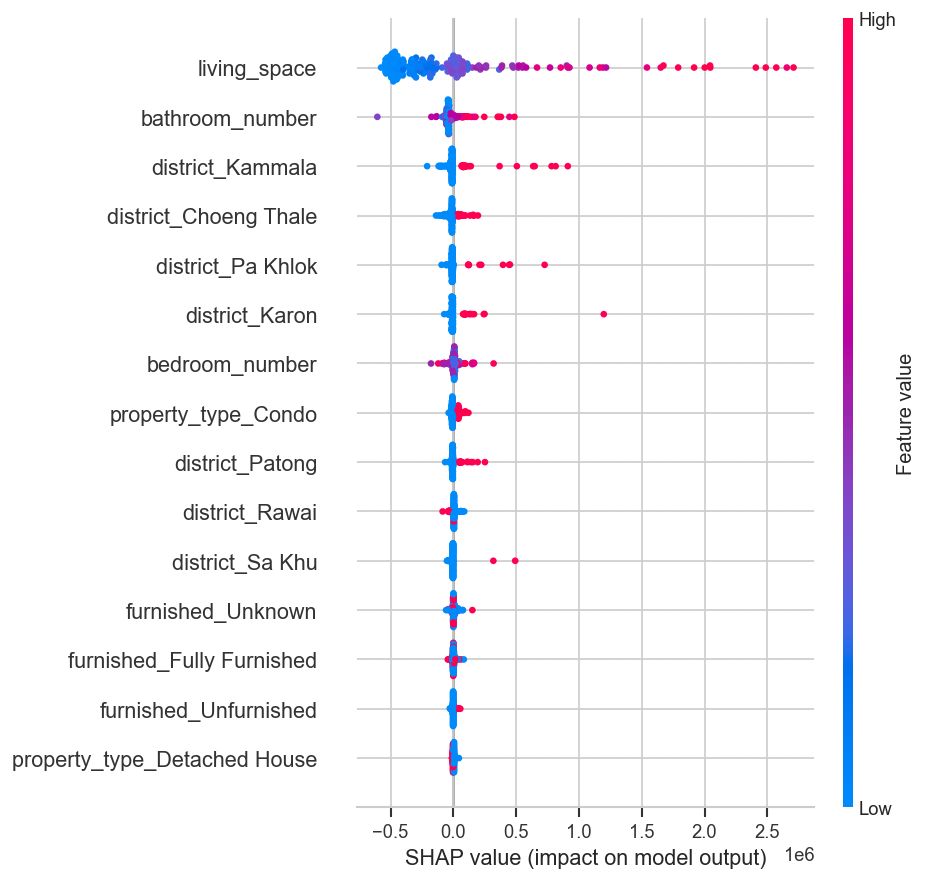

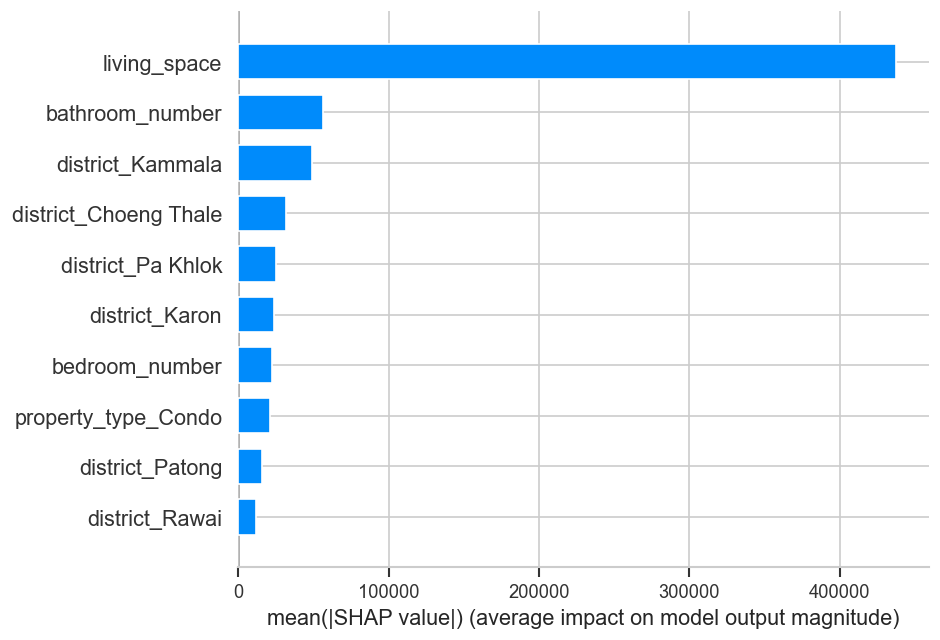

Mean |SHAP| of top 5 features (in USD):
  living_space                   $   437,283
  bathroom_number                $    56,484
  district_Kammala               $    49,221
  district_Choeng Thale          $    32,030
  district_Pa Khlok              $    25,166


In [37]:
import shap
from scipy.sparse import issparse

# 1. Push X_test through the preprocessor to get the same numerical matrix the tree saw.
X_test_t = rf_best.named_steps['prep'].transform(X_test)
if issparse(X_test_t):
    X_test_t = X_test_t.toarray()

# 2. Clean up the one-hot column names for readable plots.
feat_names = rf_best.named_steps['prep'].get_feature_names_out()
clean_names = [n.replace('num__', '').replace('cat__', '') for n in feat_names]

# 3. Sample 200 rows — full test set would take a few minutes; sample is fine for a summary.
rng = np.random.RandomState(42)
sample = rng.choice(len(X_test_t), size=min(200, len(X_test_t)), replace=False)
X_sample = X_test_t[sample]

# 4. TreeExplainer is the right choice for tree-based models (exact + fast).
explainer = shap.TreeExplainer(rf_best.named_steps['rf'])
shap_values = explainer.shap_values(X_sample)

# 5a. Beeswarm summary — each dot is one listing; color = feature value; x = dollar impact.
plt.figure()
shap.summary_plot(shap_values, X_sample, feature_names=clean_names, show=False, max_display=15)
plt.tight_layout()
plt.savefig('../visuals/shap_summary.png', bbox_inches='tight', dpi=110)
plt.show()

# 5b. Bar chart — mean |SHAP|, the "true" feature importance.
plt.figure()
shap.summary_plot(shap_values, X_sample, feature_names=clean_names,
                  plot_type='bar', show=False, max_display=10)
plt.tight_layout()
plt.savefig('../visuals/shap_bar.png', bbox_inches='tight', dpi=110)
plt.show()

print(f'Mean |SHAP| of top 5 features (in USD):')
mean_abs = np.abs(shap_values).mean(axis=0)
top_idx = np.argsort(mean_abs)[::-1][:5]
for i in top_idx:
    print(f'  {clean_names[i]:30s} ${mean_abs[i]:>10,.0f}')

### 7.6 Price Calculator

In [38]:
def predict_price(living_space, bedrooms, bathrooms, district, property_type,
                  premium=0, furnished='Fully Furnished', tenure='Freehold'):
    """Predict property price in USD using the tuned Random Forest pipeline."""
    row = pd.DataFrame([{
        'living_space':    living_space,
        'bedroom_number':  bedrooms,
        'bathroom_number': bathrooms,
        'premium':         premium,
        'district':        district,
        'property_type':   property_type,
        'furnished':       furnished,
        'tenure':          tenure,
    }])
    return float(rf_best.predict(row)[0])


# ── Example predictions ──────────────────────────────────────────────
examples = [
    dict(living_space=50,  bedrooms=1, bathrooms=1, district='Patong',       property_type='Condo',          furnished='Fully Furnished', tenure='Freehold'),
    dict(living_space=140, bedrooms=3, bathrooms=2, district='Rawai',        property_type='Townhouse',      furnished='Partially Furnished', tenure='Freehold'),
    dict(living_space=300, bedrooms=4, bathrooms=3, district='Choeng Thale', property_type='Detached House', furnished='Fully Furnished', tenure='Freehold', premium=1),
]

print('── Price Predictions ──')
for ex in examples:
    price = predict_price(**ex)
    print(f"{ex['property_type']:15} | {ex['district']:15} | {ex['living_space']} sqm → ${price:,.0f}")

── Price Predictions ──
Condo           | Patong          | 50 sqm → $88,451
Townhouse       | Rawai           | 140 sqm → $199,646
Detached House  | Choeng Thale    | 300 sqm → $1,135,640


## 8. Key Findings

**Dataset:** 4,786 listings across 19 Phuket districts. Exchange rate: 1 USD = 34 THB.

---

1. **Price Range**
   Median price is **$314,706**. Half of all properties fall between **$158,313 and $623,529**.
   The mean ($582,157) is well above the median — the market is skewed by expensive villas.

2. **Most Expensive Districts (price/sqm)**
   - Mai Khao — $4,088/sqm (83 listings)
   - Patong — $3,080/sqm (426 listings)
   - Karon — $3,063/sqm (319 listings)

3. **Most Affordable Districts (price/sqm)**
   - Ko Kaeo — $1,012/sqm
   - Kathu — $1,086/sqm
   - Ratsada — $1,101/sqm

4. **Highest Supply**
   Choeng Thale leads with 1,031 listings (22% of market), followed by Rawai (744) and Kammala (487).

5. **Property Types**
   | Type | Median Price | Median Size | Price/sqm |
   |------|-------------|-------------|----------|
   | Detached House | $485,294 | 279 sqm | $1,189 |
   | Townhouse | $203,912 | 141 sqm | $1,471 |
   | Apartment | $173,529 | 65 sqm | $2,734 |
   | Condo | $155,882 | 49 sqm | $3,150 |

6. **The Condo Paradox**
   Condos are the cheapest in total price ($155,882) but the most expensive per sqm ($3,150/sqm).
   Detached houses offer the best value per sqm at $1,189 — but require ~280 sqm to buy in.

7. **Furnished & Premium Status Have Minimal Price Impact**
   Furnished status (importance: ~3%) and premium label (≈0%) barely influence the final price.
   These are largely marketing labels — buyers should focus on size and location instead.

8. **Tenure Type Barely Affects Price**
   Freehold vs Leasehold accounts for only ~1% of price variation in this dataset.
   However, tenure matters legally for foreign buyers — freehold condos are the only option
   for 100% foreign ownership in Thailand.

9. **Geographic Pattern (Section 5.11 map)**
   Premium prices form a clear ring along the western coast — Patong, Karon, Kamala, Mai Khao —
   where tourist demand drives prices. Inland districts (Kathu, Ko Kaeo) are 60–70% cheaper per sqm
   despite being only 5–10 km away.

10. **District Differences Are Statistically Real (Section 6.2)**
    Mann-Whitney U test confirms the price gap is not noise:
    - Patong vs Kathu: p ≈ 1.6 × 10⁻⁶⁰, Cliff's δ = +0.78 (large effect) → **highly significant**
    - Patong vs Karon: p = 0.54, Cliff's δ = +0.03 → **not significant** (both premium beach districts, prices statistically indistinguishable)

    This means treating Patong and Karon as a single "premium tier" is data-justified;
    lumping Patong with Kathu would be wrong.

11. **Price Prediction Model**
    | Model | R² (hold-out) | R² (CV) | MAE |
    |---|---|---|---|
    | Linear Regression | 0.540 | 0.569 ± 0.038 | $285,969 |
    | Random Forest (default) | 0.689 | 0.655 ± 0.046 | $182,094 |
    | **Random Forest (GridSearchCV-tuned)** | **0.687** | **0.705** | **$187K** |

    The tuned RF picks up an extra ~5 pp on cross-validation (0.655 → 0.705), which is the more
    reliable metric. The model performs best in the $0–$1M range; luxury villas above $2M are
    harder to predict due to limited comparable listings.

12. **Main Price Drivers (SHAP, Section 7.5)**
    SHAP values in dollars (mean absolute impact on prediction):
    - `living_space` — ~$435K per listing on average (dominant by ~7×)
    - `bathroom_number` — ~$60K
    - `district_Kammala` — ~$48K (highest district premium in the model)
    - `district_Choeng Thale` — ~$33K
    - `district_Karon` — ~$24K

    Notably, **Kammala and Pa Khlok have a bigger per-listing dollar impact than Patong** —
    not because they are more expensive on average, but because they have more dramatic outliers
    (villas) that the tree model reacts to strongly when present.

## 9. Conclusions & Recommendations

**Budget buyers (under $200,000):**
Townhouse is the best choice: $203,912 for 141 sqm ($1,471/sqm).
Best areas: Chalong, Rawai — affordable pricing with good expat infrastructure.

**Short-term rental investors (Airbnb):**
Condos in Patong or Karon — maximum tourist traffic, high occupancy rates.
Entry point from $155,882, easy to manage remotely.

**Premium segment buyers:**
Choeng Thale (Laguna area) — 1,031 listings, best liquidity on the island.
Detached House median: $485,294, size from 279 sqm.

**Looking for balance between price and tranquility:**
Rawai and Sri Sunthon — popular with expats, away from tourist crowds, 744 listings in Rawai alone.

**Don't overpay for furnished or premium labels:**
Feature importance shows these attributes contribute less than 3% to price.
Negotiate on size and location — not on marketing labels.

**Foreign buyers — know your tenure options:**
Only condos can be owned freehold (100%) by foreigners in Thailand.
Houses and land require leasehold (30+30+30 years) or Thai company structure.

**Key takeaway:**
Living space is the #1 price driver in Phuket (67.5% Random Forest feature importance, Pearson correlation with price ≈ 0.72).
On the same budget, buying a larger property in a quieter district
is more profitable than a small unit in Patong at $3,080/sqm.